In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
from scipy import stats

def perform_welch(list_a, list_b):

    list_a = [x for x in list_a if x < 800.0]
    print(list_b)
    list_b = [x for x in list_b if x < 800.0]

    print(list_a, list_b)
    
    t_stat, p_value = stats.ttest_ind(list_a, list_b, equal_var=False)

    # Significance encoding
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    print(f"Welch's t-test results")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_value:.4g}")
    print(f"significance:{stars}")


In [4]:
DATASET = 'dic'

#### 1. AUC over LNK curve

In [5]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[1073.9886251236398, 7114.539564787339, 78.07583250906693, 15033.119683481702, 2034.7304648862512, 2070.1211671612264, 2059.3125618199806, 10031.637982195847]
[156.02307945928123, 263.0588526211672, 163.8191559512034, 202.9259808770194, 212.06726013847674, 162.5150016485328, 160.4975272007913, 219.67639301022086] [78.07583250906693]
Welch's t-test results
t-statistic: nan
p-value:     nan
significance:ns


#### 2. Best LNK value

In [6]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max([x for x in l if x < 800.0])

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max([x for x in l if x < 800.0])

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.9897790966040224, 0.9845037916254532, 0.9904385097263436, 0.9874711506758984, 0.987141444114738, 0.9891196834817012, 0.9897790966040224, 0.98846027035938]
[0.9891196834817012, 0.9881305637982196, 0.9874711506758984, 0.9904385097263436, 0.990108803165183, 0.9858226178700956, 0.9861523244312562, 0.9917573359709858] [0.9897790966040224, 0.9845037916254532, 0.9904385097263436, 0.9874711506758984, 0.987141444114738, 0.9891196834817012, 0.9897790966040224, 0.98846027035938]
Welch's t-test results
t-statistic: 0.2855
p-value:     0.7794
significance:ns


#### 3. LNK value after first epoch

In [7]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[0]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[0]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.9353775140125288, 0.8532805802835477, 0.9129574678536104, 0.945928123969667, 0.90702274975272, 0.9492251895812728, 0.9363666336960106, 0.9258160237388724]
[0.8941641938674579, 0.8381140784701615, 0.9228486646884272, 0.8410814375206066, 0.8137157929442795, 0.8473458621826574, 0.8189910979228486, 0.8424002637652489] [0.9353775140125288, 0.8532805802835477, 0.9129574678536104, 0.945928123969667, 0.90702274975272, 0.9492251895812728, 0.9363666336960106, 0.9258160237388724]
Welch's t-test results
t-statistic: -3.9848
p-value:     0.001443
significance:**


#### 4. LNK value after last measured epoch

In [8]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.1536432575008243, 0.9030662710187932, 0.1097922848664688, 0.0108803165182986, 0.0, 0.0, 0.0112100230794592, 0.0270359380151664]
[0.0, 0.6544675239037256, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] [0.1536432575008243, 0.9030662710187932, 0.1097922848664688, 0.0108803165182986, 0.0, 0.0, 0.0112100230794592, 0.0270359380151664]
Welch's t-test results
t-statistic: -0.5142
p-value:     0.6158
significance:ns


#### 5. LNK value at maximum counterfactual and treatment

In [9]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.985492911308935, 0.1496867787668975, 0.9719749423013518, 0.1589185624793933, 0.0544015825914935, 0.520936366633696, 0.9521925486317178, 0.3791625453346522]
[0.9891196834817012, 0.9881305637982196, 0.9874711506758984, 0.9904385097263436, 0.990108803165183, 0.9858226178700956, 0.9861523244312562, 0.9917573359709858] [0.985492911308935, 0.1496867787668975, 0.9719749423013518, 0.1589185624793933, 0.0544015825914935, 0.520936366633696, 0.9521925486317178, 0.3791625453346522]
Welch's t-test results
t-statistic: 3.3144
p-value:     0.01286
significance:*


In [10]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

[0.938344873062974, 0.7665677546983185, 0.9212001318826244, 0.9301022090339598, 0.9699967029343884, 0.7477744807121662, 0.3821299043850973, 0.9653808110781404]
[0.9904385097263436] [0.938344873062974, 0.7665677546983185, 0.9212001318826244, 0.9301022090339598, 0.9699967029343884, 0.7477744807121662, 0.3821299043850973, 0.9653808110781404]
Welch's t-test results
t-statistic: nan
p-value:     nan
significance:ns


#### 6. Per-Epoch t-test

In [11]:
withs = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()
    withs.append(l)

withouts = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()
    withouts.append(l)


withs = np.array(withs)
withouts = np.array(withouts)


for idx in range(300):
    a = list(withs[:, idx])
    b = list(withouts[:, idx])

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    print(idx, t_stat, p_value, sep='\t')

0	-3.9847735310070194	0.0014426102061203209
1	-2.4179432589182466	0.02983128169372388
2	-3.7521474335599905	0.0032643708193216526
3	2.0231200219665593	0.06334675443666964
4	4.610806815551504	0.002209274740067874
5	2.432383365886976	0.04475100353163554
6	3.057624790320465	0.018195783458835855
7	1.7168538906118382	0.12903766216877183
8	1.3149276546038786	0.21729686798621156
9	3.1706276062339223	0.014629308627209514
10	1.4137180008573282	0.18065096024449923
11	3.927354137620216	0.005141810135148786
12	5.2888744849623865	0.0011015319406717581
13	2.1435738189544398	0.05592560112422747
14	3.504265204735437	0.009182545978998898
15	-0.9956614202654857	0.3525791261644906
16	-0.995658631848492	0.35258038781149414
17	3.820583706784504	0.00405664891896288
18	3.1597997892094645	0.014729834698944223
19	-0.9973668851221823	0.3518066572227666
20	3.5148729978714615	0.004220797790533341
21	-0.9975974834846066	0.3517023175811918
22	2.9983888024124195	0.015578347417711596
23	3.570073637904714	0.0081488570

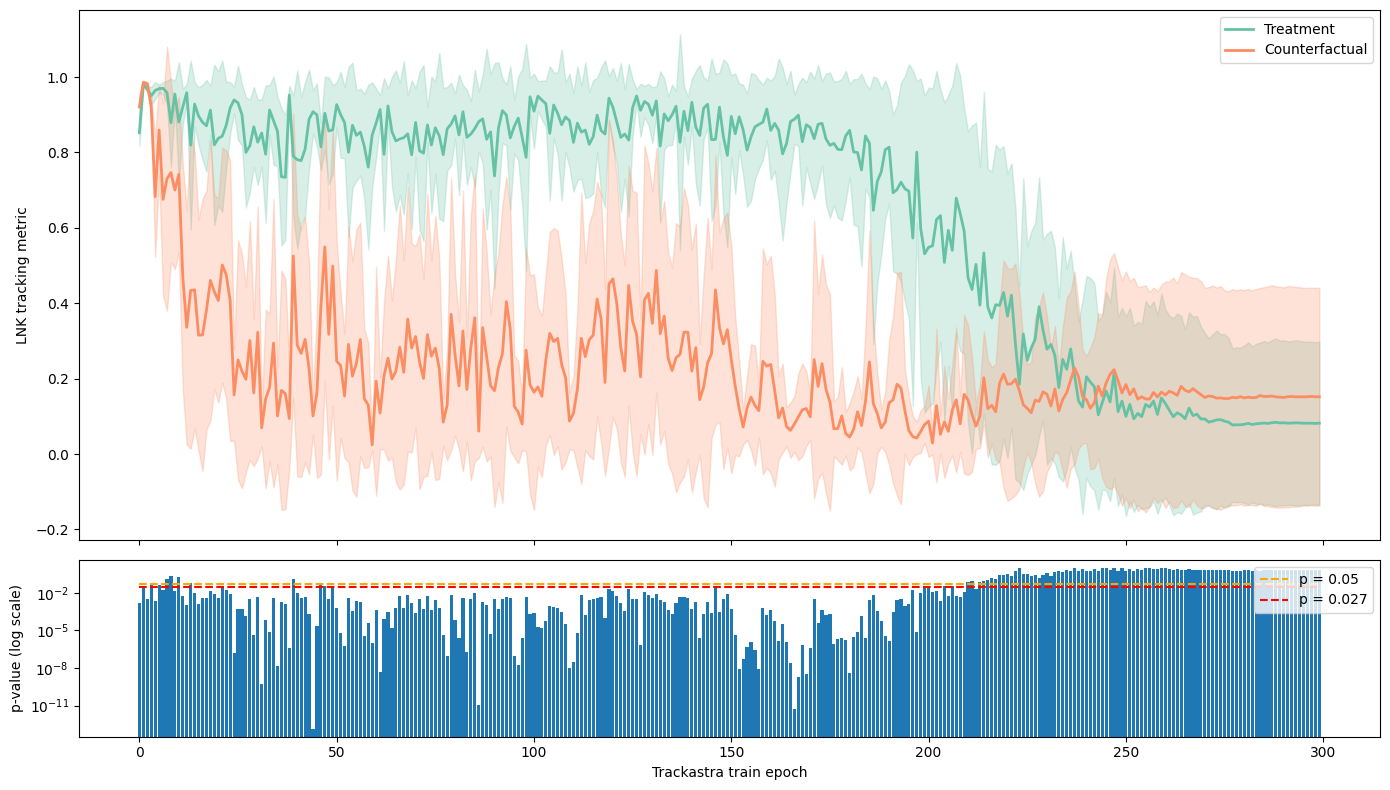

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# -------------------------
# 1) Load your runs (WITH / WITHOUT)
# -------------------------
withs = []
for fname in sorted(os.listdir(f"effects/{DATASET}/with/")):
    df = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = [x if x < 800.0 else None for x in df["LNK"].to_numpy()]
    last = 0.0
    for idx in range(len(l)):
        if l[idx] is None:
            l[idx] = last
        else:
            last = l[idx]
    withs.append(l)

withouts = []
for fname in sorted(os.listdir(f"effects/{DATASET}/without/")):
    df = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = [x if x < 800.0 else None for x in df["LNK"].to_numpy()]
    last = 0.0
    for idx in range(len(l)):
        if l[idx] is None:
            l[idx] = last
        else:
            last = l[idx]
    withouts.append(l)

# Ensure all runs have the same length (truncate to min length if not)
minlen = min(min(map(len, withs)), min(map(len, withouts)))
withs = np.stack([x[:minlen] for x in withs], axis=0)       # shape: (n_runs, T)
withouts = np.stack([x[:minlen] for x in withouts], axis=0) # shape: (n_runs, T)

# -------------------------
# 2) Plot helper: mean ± std shading
# -------------------------
cmap = mpl.colormaps["Set2"]
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, arr2d, color, label):
    """
    arr2d: shape (n_runs, T)
    """
    mean = arr2d.mean(axis=0)
    std  = arr2d.std(axis=0, ddof=0)
    x = np.arange(arr2d.shape[1])

    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25)

# -------------------------
# 3) Compute per-index p-values (Welch by default; set equal_var=True for Student)
# -------------------------
pvals = np.empty(minlen, dtype=float)
tstats = np.empty(minlen, dtype=float)

for idx in range(minlen):
    w = withs[:, idx]
    wo = withouts[:, idx]
    res = stats.ttest_ind(w, wo, equal_var=False, nan_policy="omit")
    tstats[idx] = res.statistic
    pvals[idx]  = res.pvalue

x = np.arange(minlen)

# -------------------------
# 4) Build the combined figure (top: means; bottom: significance)
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TOP ---
plot_mean_shaded(ax_top, withs, ca, "Treatment")
plot_mean_shaded(ax_top, withouts, cb, "Counterfactual")
ax_top.set_ylabel("LNK tracking metric")  # or "Score" / your metric name
# Optional: uncomment if you want the same y-limits as your example
# ax_top.set_ylim(0.90, 1.0)
ax_top.legend(loc="best")

# --- BOTTOM ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("p-value (log scale)")
ax_bottom.set_xlabel("Trackastra train epoch")

# threshold lines
ax_bottom.hlines(0.05, x.min(), x.max(), color="orange", linestyle="--", label="p = 0.05")
ax_bottom.hlines(0.027, x.min(), x.max(), color="red", linestyle="--", label="p = 0.027")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("fin_time_DIC.pdf", bbox_inches="tight")
plt.show()
